In [2]:
from dynamodelx import BnnRegressor
from dynamodelx.plots import draw_plots
from sklearn.datasets import fetch_california_housing

In [3]:
data = fetch_california_housing()
X, y = data.data, data.target

In [6]:
bnn = BnnRegressor(
    model_size='small',
    input_dim=X.shape[1],
    output_dim = 1,
    device = 'cuda',
    hidden_activation = 'gelu',
    optimizer = 'adam',
    mc_samples = 20,
    custom_architecture = None,
    return_metrics = True,
    auto_build = True
)

Model Configuration:

  Model Size:         small
  Input Dimension:    8
  Output Dimension:   1
  Loss                Negative ELBO Loss
  Device:             cuda
  Hidden Activation:  gelu
  Optimizer:          adam
  Custom Architecture:None

Building the model ...

        Model Summary (BNN)         
Layer (name)                   Shape                Param #   
--------------------------------------------------------------
weight_mu.0                    (64, 8)              512       
weight_mu.1                    (32, 64)             2048      
weight_mu.2                    (2, 32)              64        
weight_log_var.0               (64, 8)              512       
weight_log_var.1               (32, 64)             2048      
weight_log_var.2               (2, 32)              64        
bias_mu.0                      (64,)                64        
bias_mu.1                      (32,)                32        
bias_mu.2                      (2,)                 2        

In [7]:
performance = bnn.train(X=X, y=y, epochs=50, learning_rate = 0.01, momentum=None, val_size=0.2, test_size=0.1, batch_size=120, temp_lr=0.01, temp_epochs=100)

Average train loss per sample : 0.68 
Average validation loss per sample : 0.51
Average Test Loss: 0.58

   PICP & MPIW across confidence levels on test data
   10% → PICP: 0.1192 │ MPIW: 0.1271
   20% → PICP: 0.2316 │ MPIW: 0.2562
   30% → PICP: 0.3474 │ MPIW: 0.3897
   40% → PICP: 0.4482 │ MPIW: 0.5304
   50% → PICP: 0.5475 │ MPIW: 0.6822
   60% → PICP: 0.6492 │ MPIW: 0.8512
   70% → PICP: 0.7582 │ MPIW: 1.0482
   80% → PICP: 0.8445 │ MPIW: 1.2961
   90% → PICP: 0.9201 │ MPIW: 1.6635
Calibration Error : 0.30


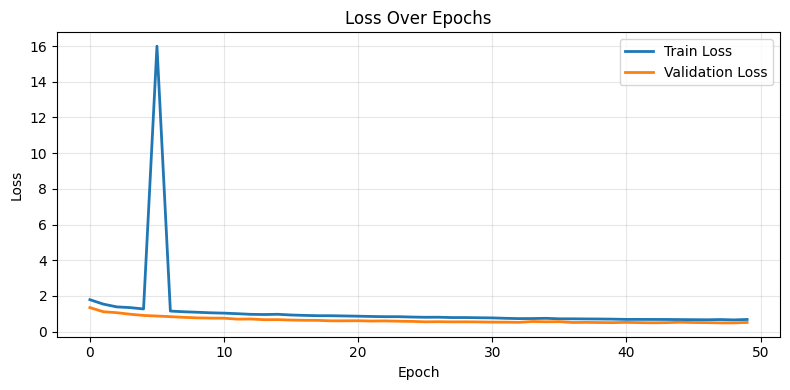

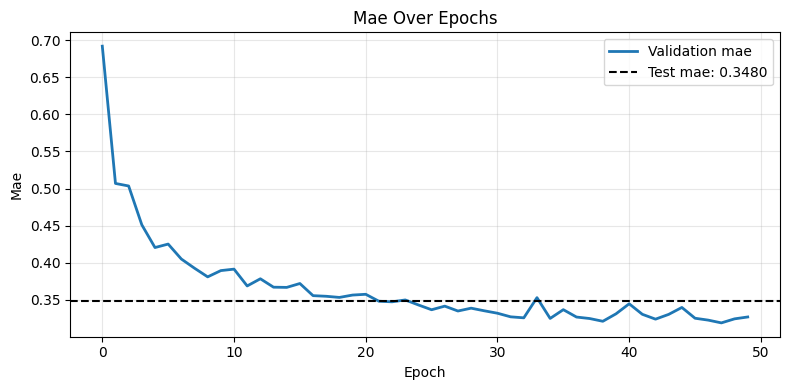

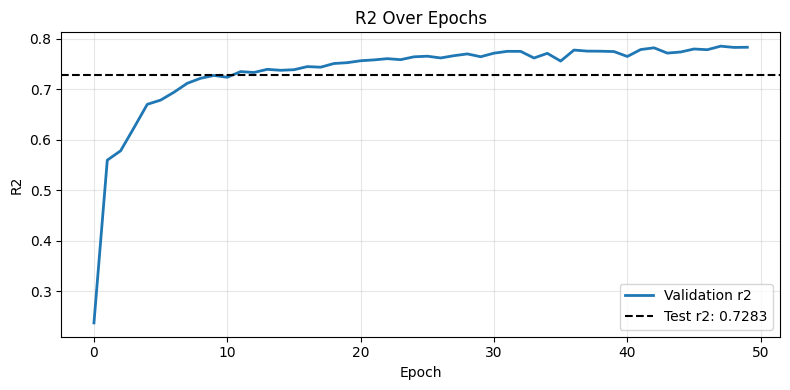

In [8]:
draw_plots(performance)

In [9]:
bnn.predict(X[:5])

(array([[4.296406 ],
        [4.323492 ],
        [4.3864746],
        [3.4839249],
        [2.7498658]], dtype=float32),
 array([[1.1079967 ],
        [0.68101597],
        [1.2646419 ],
        [0.81748855],
        [0.7900856 ]], dtype=float32))

In [10]:
bnn.save(parameters_path='california_housing_bnn.pt', arguments_path='california_housing.pt')

Model's state successfully saved to: california_housing_bnn.pt
Model's architecture successfully saved to: california_housing.pt


In [11]:
bnn = BnnRegressor.load(parameters_path='california_housing_bnn.pt', arguments_path='california_housing.pt')
bnn.predict(X[:5])

Model Configuration:

  Model Size:         small
  Input Dimension:    8
  Output Dimension:   1
  Loss                Negative ELBO Loss
  Device:             cuda
  Hidden Activation:  gelu
  Optimizer:          adam
  Custom Architecture:None

Building the model ...

        Model Summary (BNN)         
Layer (name)                   Shape                Param #   
--------------------------------------------------------------
weight_mu.0                    (64, 8)              512       
weight_mu.1                    (32, 64)             2048      
weight_mu.2                    (2, 32)              64        
weight_log_var.0               (64, 8)              512       
weight_log_var.1               (32, 64)             2048      
weight_log_var.2               (2, 32)              64        
bias_mu.0                      (64,)                64        
bias_mu.1                      (32,)                32        
bias_mu.2                      (2,)                 2        

(array([[4.3664756],
        [4.3472986],
        [4.4022923],
        [3.424914 ],
        [2.6780171]], dtype=float32),
 array([[1.0648134 ],
        [0.72415096],
        [1.2701589 ],
        [0.7919116 ],
        [0.77972806]], dtype=float32))